# Extended Analysis: Beyond Bag-of-Words

This notebook extends the original Pre-AI vs Post-AI infrastructure outage analysis with:

1. **AI-Sentence Extraction** — keyword-based extraction of AI-related sentences for manual/LLM filtering
2. **Sentence-Level Sentiment** — sentiment on AI-mentioning vs non-AI sentences (finer than full-doc)
3. **NER + Subject-Verb-Object Triples** — who does what to whom in outage coverage
4. **Narrative Device Analysis** — how do news agencies package technical failures for public consumption?
   - Metaphor/analogy detection
   - Attribution patterns (direct quotes, expert sourcing)
   - Narrative structure (headline framing, anecdotal leads, etc.)

### Prerequisites
```bash
pip install spacy vaderSentiment textblob
python -m spacy download en_core_web_sm
# For better NER/dependency parsing (optional but recommended):
# python -m spacy download en_core_web_trf
```

In [2]:
# ============================================================
# Setup & Load Data (same as original pipeline)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import spacy
import re
import warnings
from collections import Counter, defaultdict
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Load spaCy — use en_core_web_sm (or en_core_web_trf for better accuracy)
nlp = spacy.load("en_core_web_sm")
vader = SentimentIntensityAnalyzer()

# ---------- CHANGE THIS ----------
#BASE = "/Users/haonan/Documents/UChicago/MACSS/MACS30122/group_project"
# ----------------------------------
df_all = pd.read_csv("merged_relevant_articles.csv")
df_all["pub_date"] = pd.to_datetime(df_all["pub_date"], utc=True, errors="coerce")

# Guardian full-text subset (primary analysis)
df_gd = df_all[(df_all["source"] == "guardian") & (df_all["has_full_text"] == True)].copy()

# Ensure 'text_for_analysis' column exists (fallback to 'full_text' or 'text')
for col in ["text_for_analysis", "full_text", "text"]:
    if col in df_gd.columns:
        df_gd["text_for_analysis"] = df_gd[col]
        break
else:
    raise ValueError("No text column found. Expected 'text_for_analysis', 'full_text', or 'text'.")

# Drop rows with missing text
df_gd = df_gd.dropna(subset=["text_for_analysis"])

print(f"Loaded {len(df_gd)} Guardian articles")
print(df_gd.groupby(["era", "event"]).size())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00
Loaded 269 Guardian articles
era      event            
post_ai  aws_2025              28
         azure_2025             2
         crowdstrike_2024      54
         google_cloud_2025     47
pre_ai   aws_2021               1
         facebook_2021        114
         fastly_2021           18
         google_2020            5
dtype: int64


---
## Module 1: AI-Sentence Extraction & Filtering

**Goal:** Extract every sentence that mentions AI-related concepts, producing a focused
sub-corpus for (a) manual validation, (b) LLM-based relevance filtering, and
(c) sentence-level sentiment comparison.

This addresses the scarcity problem: even if an article only mentions AI once in passing,
we capture that exact sentence for close reading.

In [3]:
# ============================================================
# Define AI keyword taxonomy & extract sentences
# ============================================================

# Tiered keywords: broad → specific, so we can filter progressively
AI_KEYWORDS = {
    "core_ai": [
        "artificial intelligence", "machine learning", "deep learning",
        "neural network", "large language model", "generative ai",
        "chatgpt", "openai", "deepmind", "anthropic",
        "computer vision", "natural language processing",
        r"\bllms?\b",           # "llm" / "llms" as standalone words only
        r"\bgpt[- ]?\d?\b",   # GPT, GPT-4, GPT 3, etc.
    ],
    "ai_adjacent": [
        r"\bai\b",  # regex word-boundary match for standalone "AI"
        r"\bai-\w+",  # "AI-powered", "AI-driven", etc.
        "automated decision", "automation", "intelligent system",
        "autonomous system", "model training", "data-driven",
        "algorithmic bias", "algorithmic decision",
    ],
    "tech_complexity": [
        "cloud computing", "cybersecurity", "digital infrastructure",
        "software update", "single point of failure",
        "interconnected", "cascading failure",
        "systemic risk", "technical debt", "vendor lock-in",
    ],
}

# NOTE on removed/changed keywords:
#   - "copilot": too ambiguous (aviation copilot in airline outage articles)
#   - "gemini": too ambiguous (zodiac, NASA program, crypto exchange)
#   - "complexity" / "dependency": too generic, floods results with noise
#   - "predictive": matches non-AI contexts (predictive weather, markets)
#   - bare "algorithm": far too broad; replaced with "algorithmic bias/decision"
#   - "llm" now uses word-boundary regex to avoid substring matches


def sentence_tokenize(text):
    """Split text into sentences using spaCy for accuracy."""
    doc = nlp(str(text)[:100000])  # limit to avoid memory issues
    return [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]


def match_ai_keywords(sentence, keyword_dict):
    """Return which keyword tiers match this sentence.
    Convention: keywords starting with r'\b' are treated as regex patterns;
    all others are matched as literal substrings (case-insensitive).
    """
    sent_lower = sentence.lower()
    matched_tiers = []
    matched_terms = []
    for tier, keywords in keyword_dict.items():
        for kw in keywords:
            if kw.startswith(r"\b"):
                # regex pattern
                if re.search(kw, sent_lower):
                    matched_tiers.append(tier)
                    matched_terms.append(kw)
                    break
            else:
                if kw in sent_lower:
                    matched_tiers.append(tier)
                    matched_terms.append(kw)
                    break
    return matched_tiers, matched_terms


# Extract AI-related sentences from every article
print("Extracting AI-related sentences (this may take a few minutes)...")

ai_sentence_rows = []

for idx, row in df_gd.iterrows():
    sentences = sentence_tokenize(row["text_for_analysis"])
    for sent_idx, sent in enumerate(sentences):
        tiers, terms = match_ai_keywords(sent, AI_KEYWORDS)
        if tiers:
            ai_sentence_rows.append({
                "article_idx": idx,
                "event": row["event"],
                "era": row["era"],
                "title": row["title"],
                "sentence_position": sent_idx,
                "total_sentences": len(sentences),
                "relative_position": sent_idx / max(len(sentences), 1),
                "sentence": sent,
                "matched_tiers": "|".join(sorted(set(tiers))),
                "matched_terms": "|".join(sorted(set(terms))),
                "has_core_ai": "core_ai" in tiers,
                "has_ai_adjacent": "ai_adjacent" in tiers,
                "has_tech_complexity": "tech_complexity" in tiers,
            })

df_ai_sents = pd.DataFrame(ai_sentence_rows)

print(f"\nExtracted {len(df_ai_sents)} AI-related sentences from "
      f"{df_ai_sents['article_idx'].nunique()} articles")
print(f"\nBy era:")
print(df_ai_sents.groupby("era").size())
print(f"\nBy tier:")
print(f"  core_ai:          {df_ai_sents['has_core_ai'].sum()}")
print(f"  ai_adjacent:      {df_ai_sents['has_ai_adjacent'].sum()}")
print(f"  tech_complexity:  {df_ai_sents['has_tech_complexity'].sum()}")

Extracting AI-related sentences (this may take a few minutes)...

Extracted 400 AI-related sentences from 105 articles

By era:
era
post_ai    302
pre_ai      98
dtype: int64

By tier:
  core_ai:          57
  ai_adjacent:      264
  tech_complexity:  112


In [5]:
# ============================================================
# Export for manual / LLM filtering
# ============================================================


# Preview: show 5 random core_ai sentences from each era
print("\n" + "=" * 70)
print("SAMPLE core_ai SENTENCES")
print("=" * 70)
for era in ["pre_ai", "post_ai"]:
    subset = df_ai_sents[(df_ai_sents["era"] == era) & (df_ai_sents["has_core_ai"])]
    print(f"\n--- {era.upper()} ({len(subset)} total) ---")
    sample = subset.sample(min(5, len(subset)), random_state=42)
    for _, r in sample.iterrows():
        print(f"  [{r['event']}] {r['sentence'][:120]}...")
        print(f"    matched: {r['matched_terms']}")

# ---- LLM Filtering Prompt Template ----
print("\n" + "=" * 70)
print("LLM FILTERING PROMPT TEMPLATE")
print("=" * 70)
prompt_template = """
Below are sentences extracted from news articles about digital infrastructure outages.
Each sentence was flagged because it contains AI-related keywords.

For each sentence, classify as:
- RELEVANT: The sentence meaningfully discusses AI/automation in the context of
  the outage, its causes, implications, or the broader tech ecosystem.
- IRRELEVANT: The AI keyword is incidental (e.g., "AI-powered ad targeting" in an
  article about Facebook outage but not about AI causing the outage).

Return a JSON array: [{"id": <row_index>, "label": "RELEVANT"|"IRRELEVANT", "reason": "..."}]

Sentences:
---
[PASTE SENTENCES HERE, one per line, with index]
"""
print(prompt_template)


SAMPLE core_ai SENTENCES

--- PRE_AI (7 total) ---
  [facebook_2021] The startup, which is in the testing phase, pairs FreeStyle Libre sensors with its own app to understand the effects of ...
    matched: artificial intelligence
  [facebook_2021] “A lot of diets will tell you not to eat when your sugar levels crash,” says Douglas, who is from Edinburgh and has a ma...
    matched: machine learning
  [facebook_2021] Facebook trained its artificial intelligence systems to detect and block any future attempt to livestream a shooting spr...
    matched: artificial intelligence
  [facebook_2021] “We use artificial intelligence and the age people provide at sign-up to understand if people are telling the truth abou...
    matched: artificial intelligence
  [facebook_2021] Wolfgang Tillmans’s 2011 photograph Waste Power Station depicted a world drowning in rubbish, while Richard Powers’s cel...
    matched: llm

--- POST_AI (50 total) ---
  [aws_2025] Last week alone, OpenAI released the Ch

---
## Module 1.5: Zero-Shot Classification for "Incidental" AI Mentions

**Goal:** Filter out noisy sentences where AI is mentioned but isn't the primary focus.

**Performance optimization:** The notebook uses a shared `classify_zero_shot()` helper
that provides three layers of speedup:

1. **HuggingFace Inference API** — runs BART-large-MNLI on HF's GPU servers (~10-50x faster than local CPU)
2. **Batched concurrent requests** — sends multiple sentences per API call with parallel workers (~5-10x)
3. **Deduplication** — classifies only unique texts and maps results back (variable speedup)

Set your `HF_API_TOKEN` in the cell below. If no token is provided, the notebook
falls back to the original local model (slow but functional).

```
# Get a free token at https://huggingface.co/settings/tokens
export HF_API_TOKEN="hf_..."
```


In [6]:
# ======================================================================
# Zero-Shot Classification for AI Sentence Filtering
# ======================================================================
# PERFORMANCE: The original local BART-large-MNLI on CPU takes ~1-3s per
# sentence. With hundreds of sentences across 4 classification tasks, the
# notebook took ~1 hour. This version uses:
#   1. HuggingFace Inference API (GPU-backed, ~10-50x faster per call)
#   2. Batched concurrent requests (further ~5-10x speedup)
#   3. Deduplication (classify unique sentences only, map results back)
#   4. Automatic fallback to local model if API is unavailable
# ======================================================================

import requests
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# ---------- CONFIGURATION ----------
# Option A: Set your HuggingFace API token here
# Option B: Set the environment variable HF_API_TOKEN
# Option C: Leave blank to fall back to local model (slow)
HF_API_TOKEN = os.environ.get("HF_API_TOKEN", "")  # <-- paste your token here if needed
HF_MODEL = "facebook/bart-large-mnli"
HF_API_URL = f"https://api-inference.huggingface.co/models/{HF_MODEL}"
USE_API = bool(HF_API_TOKEN)

# Batch and concurrency settings
BATCH_SIZE = 8          # sentences per API request (HF API supports batching)
MAX_WORKERS = 4         # parallel requests
RETRY_LIMIT = 3         # retries on transient failures
# ------------------------------------

if USE_API:
    print(f"Using HuggingFace Inference API (model: {HF_MODEL})")
    print(f"  Batch size: {BATCH_SIZE}, Max workers: {MAX_WORKERS}")
else:
    print("No HF_API_TOKEN found. Falling back to LOCAL model (slow).")
    print("To speed up 10-50x, set HF_API_TOKEN in env or in the cell above.")
    from transformers import pipeline as hf_pipeline
    _local_classifier = hf_pipeline("zero-shot-classification", model=HF_MODEL, device=-1)


def _api_classify_batch(sentences, candidate_labels, multi_label=False):
    """Classify a batch of sentences via HuggingFace Inference API."""
    headers = {"Authorization": f"Bearer {HF_API_TOKEN}"}
    payload = {
        "inputs": sentences,
        "parameters": {
            "candidate_labels": candidate_labels,
            "multi_label": multi_label,
        },
    }
    for attempt in range(RETRY_LIMIT):
        try:
            resp = requests.post(HF_API_URL, headers=headers, json=payload, timeout=60)
            if resp.status_code == 503:
                # Model is loading — wait and retry
                wait = resp.json().get("estimated_time", 20)
                print(f"  Model loading, waiting {wait:.0f}s...")
                time.sleep(min(wait, 60))
                continue
            resp.raise_for_status()
            results = resp.json()
            # Single sentence returns a dict, batch returns a list
            if isinstance(results, dict):
                results = [results]
            return results
        except Exception as e:
            if attempt < RETRY_LIMIT - 1:
                time.sleep(2 ** attempt)
            else:
                raise RuntimeError(f"HF API failed after {RETRY_LIMIT} attempts: {e}")
    return None


def _local_classify_batch(sentences, candidate_labels):
    """Fallback: classify using local model, one at a time."""
    results = []
    for sent in sentences:
        res = _local_classifier(sent, candidate_labels)
        results.append(res)
    return results


def classify_zero_shot(texts, candidate_labels, label_map_fn, multi_label=False):
    """
    Classify a list of texts using zero-shot classification.
    
    Args:
        texts: list of strings to classify
        candidate_labels: list of candidate label strings
        label_map_fn: function(result_dict) -> category string
        multi_label: whether to allow multiple labels
    
    Returns:
        list of category strings, same order as input texts
    """
    # Step 1: Deduplicate
    unique_texts = list(set(texts))
    text_to_result = {}
    
    print(f"  Classifying {len(unique_texts)} unique texts "
          f"({len(texts)} total, {len(texts) - len(unique_texts)} duplicates skipped)")
    
    if USE_API:
        # Step 2: Batch + parallel API calls
        batches = [unique_texts[i:i+BATCH_SIZE] for i in range(0, len(unique_texts), BATCH_SIZE)]
        completed = 0
        
        def process_batch(batch):
            return batch, _api_classify_batch(batch, candidate_labels, multi_label)
        
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [executor.submit(process_batch, batch) for batch in batches]
            for future in as_completed(futures):
                batch_texts, batch_results = future.result()
                for text, result in zip(batch_texts, batch_results):
                    text_to_result[text] = result
                completed += len(batch_texts)
                if completed % 50 == 0 or completed == len(unique_texts):
                    print(f"  Progress: {completed}/{len(unique_texts)}")
    else:
        # Local fallback (no batching benefit on CPU)
        for i, text in enumerate(unique_texts):
            results = _local_classify_batch([text], candidate_labels)
            text_to_result[text] = results[0]
            if (i + 1) % 20 == 0:
                print(f"  Progress: {i+1}/{len(unique_texts)}")
    
    # Step 3: Map results back to original order
    categories = []
    for text in texts:
        result = text_to_result.get(text)
        if result:
            categories.append(label_map_fn(result))
        else:
            categories.append("other")
    
    return categories


# ---- Classify AI relevance ----
print("\nClassifying AI sentence relevance...")

relevance_labels = [
    "artificial intelligence causing, explaining, or relating to a system failure",
    "an incidental or passing mention of artificial intelligence"
]

def relevance_map_fn(result):
    top_label = result['labels'][0]
    return "RELEVANT" if "causing, explaining" in top_label else "IRRELEVANT"

df_ai_sents['relevance_zeroshot'] = classify_zero_shot(
    df_ai_sents['sentence'].tolist(),
    relevance_labels,
    relevance_map_fn
)

df_ai_relevant = df_ai_sents[df_ai_sents['relevance_zeroshot'] == 'RELEVANT'].copy()

print("\n" + "=" * 70)
print("ZERO-SHOT FILTERING RESULTS")
print("=" * 70)
print(df_ai_sents['relevance_zeroshot'].value_counts())
print(f"\nKept {len(df_ai_relevant)} relevant AI sentences for downstream analysis.")


Loading BART-large-MNLI model for zero-shot classification...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Classifying sentences... this may take a few minutes.
ZERO-SHOT FILTERING RESULTS
relevance_zeroshot
RELEVANT      288
IRRELEVANT    112
Name: count, dtype: int64

Kept 288 relevant AI sentences for downstream analysis.


---
## Module 2: Sentence-Level Sentiment — AI vs Non-AI Sentences

**Goal:** Compare sentiment *within* articles — are sentences mentioning AI/tech-complexity
more negative, alarmist, or uncertain than surrounding sentences? This captures the
"interpretive lag" at the sentence level.

In [7]:
# ============================================================
# Sentence-level sentiment for AI vs non-AI sentences
# ============================================================

def get_sentence_sentiment(text):
    """VADER compound + TextBlob polarity for a single sentence."""
    text = str(text)
    v = vader.polarity_scores(text)
    tb = TextBlob(text)
    return v["compound"], tb.sentiment.polarity, tb.sentiment.subjectivity


# Compute sentiment for every AI-matched sentence
print("Computing sentence-level sentiment on AI sentences...")
sentiments = df_ai_relevant["sentence"].apply(
    lambda s: pd.Series(get_sentence_sentiment(s),
                        index=["vader_compound", "tb_polarity", "tb_subjectivity"])
)
df_ai_relevant = pd.concat([df_ai_relevant, sentiments], axis=1)

# Now compute sentiment for NON-AI sentences (for within-article comparison)
print("Computing background sentence sentiment (sampling non-AI sentences)...")

non_ai_rows = []
for idx, row in df_gd.iterrows():
    sentences = sentence_tokenize(row["text_for_analysis"])
    for sent_idx, sent in enumerate(sentences):
        tiers, _ = match_ai_keywords(sent, AI_KEYWORDS)
        if not tiers:  # non-AI sentence
            v_comp, tb_pol, tb_subj = get_sentence_sentiment(sent)
            non_ai_rows.append({
                "article_idx": idx,
                "era": row["era"],
                "event": row["event"],
                "sentence_type": "non_ai",
                "vader_compound": v_comp,
                "tb_polarity": tb_pol,
                "tb_subjectivity": tb_subj,
            })

df_non_ai = pd.DataFrame(non_ai_rows)

# Build comparison dataframe
df_ai_relevant["sentence_type"] = "ai_related"
compare_cols = ["era", "event", "article_idx", "sentence_type",
                "vader_compound", "tb_polarity", "tb_subjectivity"]
df_sent_compare = pd.concat([
    df_ai_relevant[compare_cols],
    df_non_ai[compare_cols]
], ignore_index=True)

print(f"\nSentence counts: {df_sent_compare['sentence_type'].value_counts().to_dict()}")
print("Done.")

Computing sentence-level sentiment on AI sentences...
Computing background sentence sentiment (sampling non-AI sentences)...

Sentence counts: {'non_ai': 12301, 'ai_related': 288}
Done.


In [8]:
# ============================================================
# Compare AI vs non-AI sentence sentiment by era
# ============================================================

print("=" * 70)
print("SENTENCE-LEVEL SENTIMENT: AI-related vs Background")
print("=" * 70)

for metric in ["vader_compound", "tb_polarity", "tb_subjectivity"]:
    print(f"\n--- {metric} ---")
    summary = df_sent_compare.groupby(["era", "sentence_type"])[metric].agg(
        ["mean", "median", "std", "count"]
    ).round(4)
    print(summary)

    # Statistical test: AI vs non-AI within each era
    for era in ["pre_ai", "post_ai"]:
        ai_vals = df_sent_compare[
            (df_sent_compare["era"] == era) &
            (df_sent_compare["sentence_type"] == "ai_related")
        ][metric].dropna()
        non_ai_vals = df_sent_compare[
            (df_sent_compare["era"] == era) &
            (df_sent_compare["sentence_type"] == "non_ai")
        ][metric].dropna()
        if len(ai_vals) > 5 and len(non_ai_vals) > 5:
            u, p = stats.mannwhitneyu(ai_vals, non_ai_vals, alternative="two-sided")
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
            print(f"  {era}: AI vs non-AI  U={u:.0f}, p={p:.4f} {sig}")

SENTENCE-LEVEL SENTIMENT: AI-related vs Background

--- vader_compound ---
                         mean  median     std  count
era     sentence_type                               
post_ai ai_related     0.0011     0.0  0.4258    197
        non_ai         0.0381     0.0  0.4232   5417
pre_ai  ai_related    -0.0670     0.0  0.4667     91
        non_ai         0.0220     0.0  0.4149   6884
  pre_ai: AI vs non-AI  U=285456, p=0.1399 n.s.
  post_ai: AI vs non-AI  U=506744, p=0.2230 n.s.

--- tb_polarity ---
                         mean  median     std  count
era     sentence_type                               
post_ai ai_related     0.0127     0.0  0.2036    197
        non_ai         0.0730     0.0  0.2295   5417
pre_ai  ai_related     0.0200     0.0  0.2703     91
        non_ai         0.0616     0.0  0.2266   6884
  pre_ai: AI vs non-AI  U=296262, p=0.3639 n.s.
  post_ai: AI vs non-AI  U=459582, p=0.0007 ***

--- tb_subjectivity ---
                         mean  median     std  cou

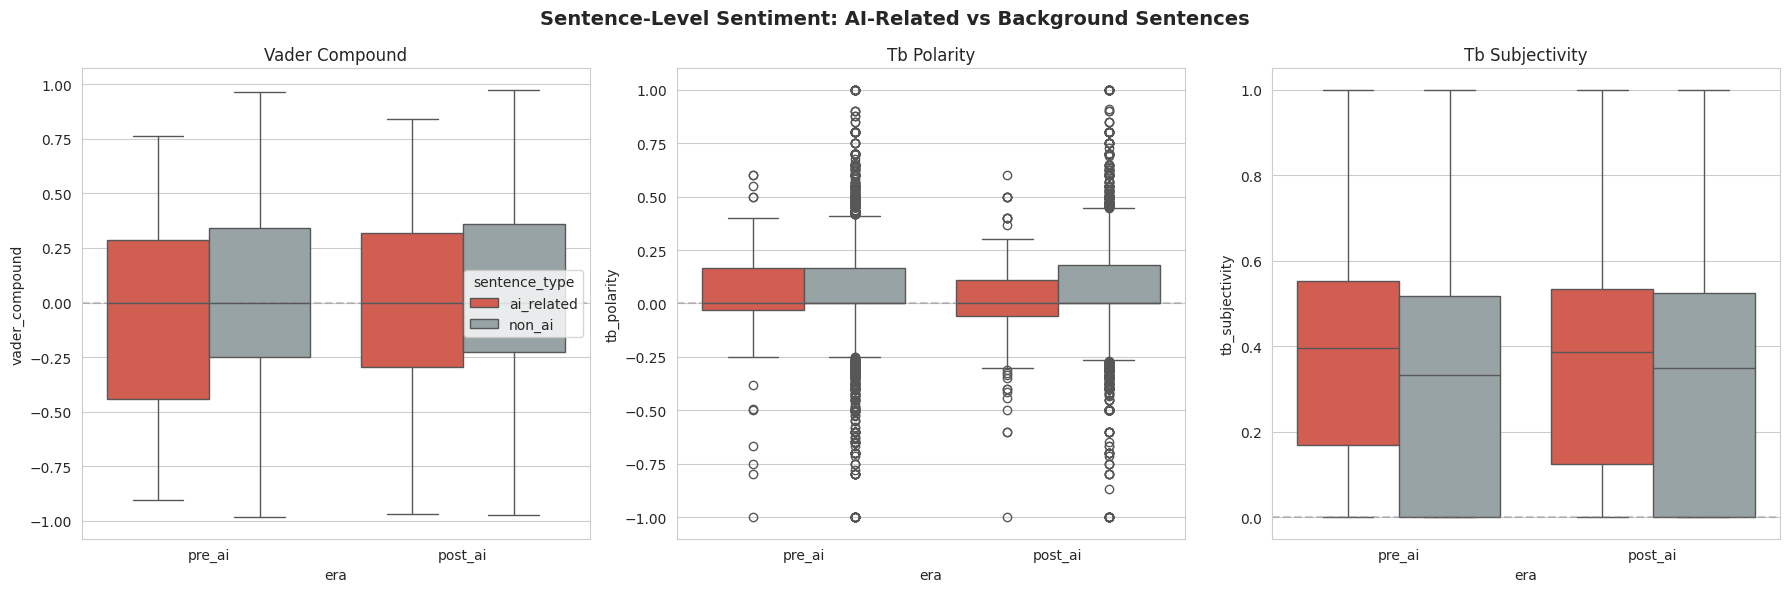

In [10]:
# ============================================================
# Visualization — Sentence-level sentiment comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(["vader_compound", "tb_polarity", "tb_subjectivity"]):
    ax = axes[i]
    sns.boxplot(
        data=df_sent_compare, x="era", y=metric,
        hue="sentence_type", ax=ax,
        palette={"ai_related": "#e74c3c", "non_ai": "#95a5a6"},
        order=["pre_ai", "post_ai"]
    )
    ax.set_title(metric.replace("_", " ").title(), fontsize=12)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.4)
    if i > 0:
        legend = ax.get_legend()
        if legend:
            legend.remove()

plt.suptitle("Sentence-Level Sentiment: AI-Related vs Background Sentences",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Module 3: NER + Subject-Verb-Object (SVO) Triple Extraction

**Goal:** Move beyond keyword counting to understand *who acts on whom*.
Using spaCy's dependency parser, we extract (Subject, Verb, Object) triples
to see how agency is grammatically constructed in outage coverage.

Key questions:
- Are companies subjects (active agents) or objects (things acted upon)?
- Do Post-AI articles give agency to "AI" / "algorithm" / "system" as subjects?
- Is the user framed as passive victim or active participant?

In [11]:
# ============================================================
# SVO Triple Extraction using spaCy dependency parse
# ============================================================

def extract_svo_triples(doc):
    """
    Extract Subject-Verb-Object triples from a spaCy Doc.
    Returns list of (subject_text, verb_text, object_text, full_sentence) tuples.
    """
    triples = []
    for sent in doc.sents:
        for token in sent:
            if token.dep_ == "ROOT" and token.pos_ == "VERB":
                verb = token
                # Find subject
                subjects = [child for child in verb.children
                            if child.dep_ in ("nsubj", "nsubjpass")]
                # Find object
                objects = [child for child in verb.children
                           if child.dep_ in ("dobj", "attr", "pobj")]
                # If no direct object, check prepositional objects
                if not objects:
                    for child in verb.children:
                        if child.dep_ == "prep":
                            for grandchild in child.children:
                                if grandchild.dep_ == "pobj":
                                    objects.append(grandchild)

                for subj in subjects:
                    # Get the full noun phrase for subject
                    subj_phrase = get_noun_phrase(subj)
                    is_passive = subj.dep_ == "nsubjpass"
                    verb_text = get_verb_phrase(verb, is_passive)

                    if objects:
                        for obj in objects:
                            obj_phrase = get_noun_phrase(obj)
                            triples.append({
                                "subject": subj_phrase,
                                "verb": verb_text,
                                "object": obj_phrase,
                                "is_passive": is_passive,
                                "sentence": sent.text.strip(),
                            })
                    else:
                        triples.append({
                            "subject": subj_phrase,
                            "verb": verb_text,
                            "object": "[none]",
                            "is_passive": is_passive,
                            "sentence": sent.text.strip(),
                        })
    return triples


def get_noun_phrase(token):
    """Expand a token to its full noun phrase.
    Prefer spaCy noun_chunks (handles clause boundaries correctly),
    fall back to conservative subtree walk if no chunk found."""
    # First try: find the noun chunk that contains this token
    doc = token.doc
    for chunk in doc.noun_chunks:
        if token.i >= chunk.start and token.i < chunk.end:
            return chunk.text.strip()

    # Fallback: walk only direct modifiers, avoiding clause-level dependents
    safe_deps = {"det", "amod", "compound", "poss", "nummod", "nmod", "case"}
    phrase_tokens = [token]
    for child in token.children:
        if child.dep_ in safe_deps:
            phrase_tokens.append(child)
            for grandchild in child.children:
                if grandchild.dep_ in safe_deps:
                    phrase_tokens.append(grandchild)
    phrase_tokens = sorted(phrase_tokens, key=lambda t: t.i)[:8]
    return " ".join([t.text for t in phrase_tokens]).strip()


def get_verb_phrase(verb, is_passive):
    """Get verb with auxiliaries, ordered by token position."""
    aux_tokens = [(child.i, child.text) for child in verb.children
                  if child.dep_ in ("aux", "auxpass", "neg")]
    # Sort auxiliaries by their position in the sentence, then append the main verb lemma
    aux_tokens.sort(key=lambda x: x[0])
    aux_texts = [t[1] for t in aux_tokens]
    if aux_texts:
        return " ".join(aux_texts + [verb.lemma_])
    return verb.lemma_


# Run SVO extraction on AI-related sentences only (focused analysis)
print("Extracting SVO triples from AI-related sentences...")

all_triples = []
for _, row in df_ai_relevant.iterrows():
    doc = nlp(row["sentence"])
    triples = extract_svo_triples(doc)
    for t in triples:
        t["era"] = row["era"]
        t["event"] = row["event"]
        t["article_idx"] = row["article_idx"]
        t["matched_tiers"] = row["matched_tiers"]
    all_triples.extend(triples)

df_triples = pd.DataFrame(all_triples)
print(f"Extracted {len(df_triples)} SVO triples")
print(f"\nBy era: {df_triples.groupby('era').size().to_dict()}")

Extracting SVO triples from AI-related sentences...
Extracted 244 SVO triples

By era: {'post_ai': 167, 'pre_ai': 77}


In [29]:
# ======================================================================
# Semantic SVO Categorization for Subjects AND Objects
# ======================================================================

# 1. Gather all unique subjects and objects to minimize model processing time
unique_subjects = df_triples['subject'].dropna().unique().tolist()
unique_objects = df_triples['object'].dropna().unique().tolist()

# Combine and remove duplicates and empty strings
unique_entities = list(set(unique_subjects + unique_objects))
unique_entities = [e for e in unique_entities if len(str(e).strip()) > 1]

# 2. Define the candidate labels and how they map to your short categories
# NOTE: Labels designed to be mutually exclusive. "Company" = the corporate
# actor (Facebook, CrowdStrike). "Tech system" = the infrastructure itself
# (the server, the update, the software). Ambiguous entities like "AWS" may
# classify either way — inherent limitation of zero-shot NLI.
entity_labels = [
    "a named technology company or corporate brand like Facebook, Google, or Microsoft",
    "an artificial intelligence model, algorithm, or AI system",
    "a piece of technology infrastructure such as a server, network, software, or update",
    "end users, the general public, or customers affected by a service",
    "a government body, regulator, or legislative entity",
    "a named human person such as a CEO, engineer, or spokesperson"
]

label_map = {
    "a named technology company or corporate brand like Facebook, Google, or Microsoft": "company",
    "an artificial intelligence model, algorithm, or AI system": "ai_system",
    "a piece of technology infrastructure such as a server, network, software, or update": "tech_system",
    "end users, the general public, or customers affected by a service": "user_public",
    "a government body, regulator, or legislative entity": "government",
    "a named human person such as a CEO, engineer, or spokesperson": "executive"
}

CONFIDENCE_THRESHOLD = 0.40  # with 6 classes, random baseline is ~0.17

# 3. Pre-filter: skip pronouns, stopwords, and noise BEFORE sending to model
skip_tokens = {
    # pronouns
    'it', 'its', 'they', 'them', 'their', 'he', 'him', 'his', 'she', 'her',
    'this', 'that', 'these', 'those', 'which', 'who', 'whom', 'what',
    'i', 'me', 'my', 'we', 'us', 'our', 'you', 'your',
    'itself', 'themselves', 'himself', 'herself',
    # determiners / filler
    'the', 'a', 'an', 'there', 'here', 'some', 'all', 'many', 'most',
    # placeholder from SVO extraction
    '[none]',
}

entity_to_category = {}
entities_to_classify = []

for entity in unique_entities:
    ent_str = str(entity).lower().strip()

    if ent_str in skip_tokens or len(ent_str) <= 1 or ent_str.isdigit():
        entity_to_category[entity] = 'pronoun'
        continue

    words = ent_str.split()
    if all(w in skip_tokens for w in words):
        entity_to_category[entity] = 'pronoun'
        continue

    entities_to_classify.append(entity)

print(f"Pre-filtered: {len(unique_entities) - len(entities_to_classify)} "
      f"pronouns/stopwords skipped, {len(entities_to_classify)} entities to classify")

# 4. Batch-classify remaining entities using the shared helper
def entity_map_fn(result):
    best_label = result['labels'][0]
    score = result['scores'][0]
    if score > CONFIDENCE_THRESHOLD:
        return label_map.get(best_label, 'other')
    return 'other'

entity_categories = classify_zero_shot(
    entities_to_classify,
    entity_labels,
    entity_map_fn
)

for entity, cat in zip(entities_to_classify, entity_categories):
    entity_to_category[entity] = cat

# 5. Map the classifications back to BOTH subjects and objects
df_triples['subject_category'] = df_triples['subject'].map(entity_to_category).fillna('other')
df_triples['object_category'] = df_triples['object'].map(entity_to_category).fillna('other')

# 6. Print distributions
print("\n" + "="*70)
print("SUBJECT (AGENT) DISTRIBUTION BY ERA")
print("="*70)
new_subj_dist = pd.crosstab(df_triples["era"], df_triples["subject_category"], normalize="index") * 100
print(new_subj_dist.round(1))

print("\n" + "="*70)
print("OBJECT (PATIENT/TARGET) DISTRIBUTION BY ERA")
print("="*70)
new_obj_dist = pd.crosstab(df_triples["era"], df_triples["object_category"], normalize="index") * 100
print(new_obj_dist.round(1))


Classifying 281 unique entities using Zero-Shot... This may take a minute.

NEW SUBJECT (AGENT) DISTRIBUTION BY ERA
subject_category  ai_system  company  executive  government  other  \
era                                                                  
post_ai                10.6     28.4       19.9         5.7   16.3   
pre_ai                  6.9     29.3       31.0        10.3    5.2   

subject_category  tech_system  user_public  
era                                         
post_ai                   6.4         12.8  
pre_ai                    6.9         10.3  

NEW OBJECT (PATIENT/TARGET) DISTRIBUTION BY ERA
object_category  ai_system  company  executive  government  other  pronoun  \
era                                                                          
post_ai                5.0     11.3        2.1         3.5   61.7      0.7   
pre_ai                 6.9      5.2        5.2         3.4   60.3      0.0   

object_category  tech_system  user_public  
era              

Classifying 124 unique action verbs using Zero-Shot...

HOW IS TECHNOLOGY'S ACTION FRAMED? (Verb Category by Era)
verb_category  cognitive_autonomous  communicative  impact_disruption  \
era                                                                     
post_ai                        11.1           55.6               33.3   
pre_ai                         25.0           25.0               25.0   

verb_category  mechanical_technical  
era                                  
post_ai                         0.0  
pre_ai                         25.0  


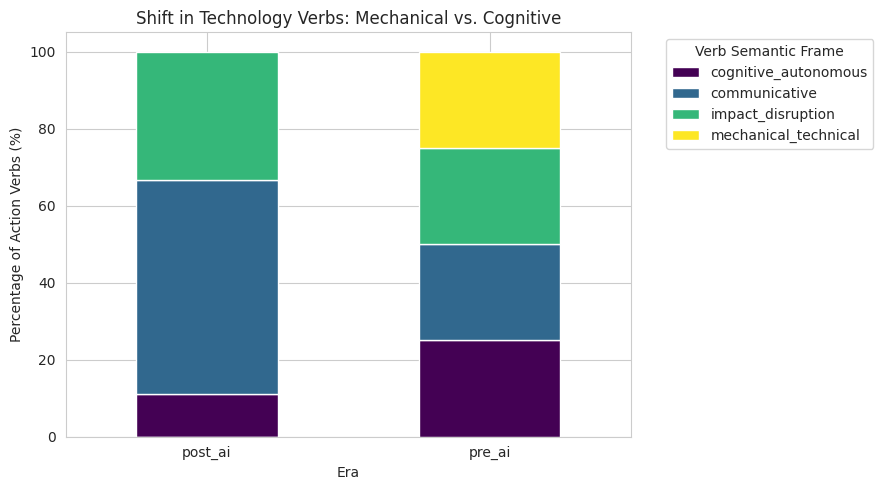

In [30]:
# ======================================================================
# Verb Semantic Frame Classification
# ======================================================================

# Stop-verbs: auxiliaries and very generic verbs with no narrative signal.
# NOTE: 'say' is intentionally kept OUT — it is the most common communicative
# verb and should classify into the 'communicative' frame, not be discarded.
stop_verbs = [
    'be', 'have', 'do', 'will', 'can', 'may', 'could', 'would', 'should', 'might',
    'come', 'seem', 'appear', 'become', 'go', 'get', 'let', 'keep',
    'make', 'take', 'give', 'put',
]
unique_verbs = [v for v in df_triples['verb'].dropna().unique() if str(v).lower() not in stop_verbs]

print(f"Classifying {len(unique_verbs)} unique action verbs...")

# NOTE: "mechanical" = HOW the system broke internally; "impact" = downstream
# CONSEQUENCE on users/services. Sharper labels reduce classifier confusion.
verb_labels = [
    "a cognitive or human-like action implying autonomy or intelligence (e.g., decide, learn, predict, hallucinate)",
    "a technical malfunction or internal system failure (e.g., crash, overload, malfunction, break, glitch)",
    "a downstream consequence or impact on people and services (e.g., disrupt, affect, strand, leave without, halt)",
    "a communicative or reporting action (e.g., say, state, warn, announce, publish, confirm)"
]

verb_label_map = {
    "a cognitive or human-like action implying autonomy or intelligence (e.g., decide, learn, predict, hallucinate)": "cognitive_autonomous",
    "a technical malfunction or internal system failure (e.g., crash, overload, malfunction, break, glitch)": "mechanical_technical",
    "a downstream consequence or impact on people and services (e.g., disrupt, affect, strand, leave without, halt)": "impact_disruption",
    "a communicative or reporting action (e.g., say, state, warn, announce, publish, confirm)": "communicative"
}

VERB_CONFIDENCE = 0.35

def verb_map_fn(result):
    best_label = result['labels'][0]
    score = result['scores'][0]
    if score > VERB_CONFIDENCE:
        return verb_label_map.get(best_label, 'other')
    return 'other'

verb_categories = classify_zero_shot(
    unique_verbs,
    verb_labels,
    verb_map_fn
)

verb_to_category = dict(zip(unique_verbs, verb_categories))

# Map stop-verbs to 'auxiliary_stop' so they don't clutter 'other'
for sv in stop_verbs:
    verb_to_category[sv] = 'auxiliary_stop'

# Map back to the dataframe
df_triples['verb_category'] = df_triples['verb'].map(verb_to_category).fillna('other')

tech_subjects = ['ai_system', 'tech_system']
tech_triples = df_triples[df_triples['subject_category'].isin(tech_subjects)]

print("\n" + "="*70)
print("HOW IS TECHNOLOGY'S ACTION FRAMED? (Verb Category by Era)")
print("="*70)

# Filter out auxiliary verbs for the percentage breakdown
meaningful_tech_triples = tech_triples[~tech_triples['verb_category'].isin(['auxiliary_stop', 'other'])]

if not meaningful_tech_triples.empty:
    verb_dist = pd.crosstab(meaningful_tech_triples["era"], meaningful_tech_triples["verb_category"], normalize="index") * 100
    print(verb_dist.round(1))

    ax = verb_dist.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="viridis")
    plt.title("Shift in Technology Verbs: Mechanical vs. Cognitive")
    plt.ylabel("Percentage of Action Verbs (%)")
    plt.xlabel("Era")
    plt.xticks(rotation=0)
    plt.legend(title="Verb Semantic Frame", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough technology subjects found to calculate verb distribution.")


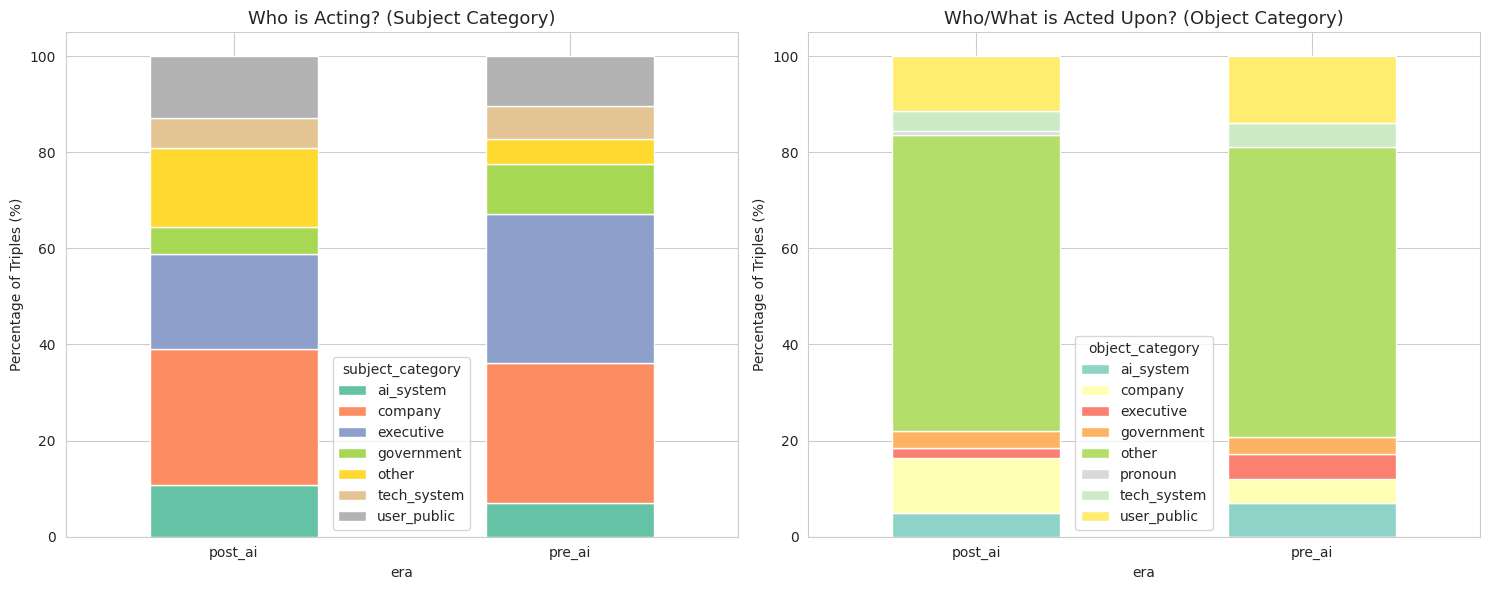


TOP SEMANTIC NARRATIVE PATTERNS: [Subject] -> [Verb Frame] -> [Object]

--- PRE_AI ---
[company] --(communicative)--> [other] : 5 occurrences
[executive] --(communicative)--> [other] : 4 occurrences
[company] --(impact_disruption)--> [other] : 3 occurrences
[user_public] --(communicative)--> [other] : 3 occurrences
[company] --(communicative)--> [executive] : 2 occurrences

--- POST_AI ---
[company] --(communicative)--> [other] : 10 occurrences
[company] --(impact_disruption)--> [other] : 9 occurrences
[other] --(communicative)--> [other] : 8 occurrences
[executive] --(communicative)--> [other] : 7 occurrences
[other] --(impact_disruption)--> [other] : 5 occurrences


In [33]:
# ======================================================================
# Semantic SVO Agency Patterns & Top Actions
# ======================================================================
import matplotlib.pyplot as plt

# 1. Plot the new Subject and Object Distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

subj_dist = pd.crosstab(df_triples["era"], df_triples["subject_category"], normalize="index") * 100
subj_dist.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Who is Acting? (Subject Category)", fontsize=13)
axes[0].set_ylabel("Percentage of Triples (%)")
axes[0].tick_params(axis='x', rotation=0)

obj_dist = pd.crosstab(df_triples["era"], df_triples["object_category"], normalize="index") * 100
obj_dist.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set3")
axes[1].set_title("Who/What is Acted Upon? (Object Category)", fontsize=13)
axes[1].set_ylabel("Percentage of Triples (%)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 2. Extract Top Semantic Narrative Patterns
print("\n" + "="*70)
print("TOP SEMANTIC NARRATIVE PATTERNS: [Subject] -> [Verb Frame] -> [Object]")
print("="*70)

# Group by the new semantic categories
svo_patterns = df_triples.groupby(['era', 'subject_category', 'verb_category', 'object_category']).size().reset_index(name='count')
svo_patterns = svo_patterns.sort_values(['era', 'count'], ascending=[True, False])

for era in ['pre_ai', 'post_ai']:
    print(f"\n--- {era.upper()} ---")
    # Exclude useless pronouns and aux verbs for cleaner patterns
    clean_patterns = svo_patterns[
        (svo_patterns['era'] == era) &
        (svo_patterns['subject_category'] != 'pronoun') &
        (svo_patterns['verb_category'] != 'auxiliary_stop')
    ]

    for _, row in clean_patterns.head(5).iterrows():
        print(f"[{row['subject_category']}] --({row['verb_category']})--> [{row['object_category']}] : {row['count']} occurrences")

In [34]:
# ============================================================
# CELL 10: Named Entity Recognition — who gets mentioned?
# ============================================================

print("Running NER on all articles...")

ner_results = []

for idx, row in df_gd.iterrows():
    doc = nlp(str(row["text_for_analysis"])[:100000])
    for ent in doc.ents:
        if ent.label_ in ("ORG", "PERSON", "GPE", "PRODUCT", "EVENT", "LAW"):
            # Normalize: strip whitespace, collapse internal whitespace
            entity_text = " ".join(ent.text.split())
            if len(entity_text) < 2:
                continue  # skip single-char entities (noise)
            ner_results.append({
                "article_idx": idx,
                "era": row["era"],
                "event": row["event"],
                "entity_text": entity_text,
                "entity_label": ent.label_,
            })

df_ner = pd.DataFrame(ner_results)
print(f"Extracted {len(df_ner)} named entities")

# Top entities by era
print("\n" + "=" * 70)
print("TOP NAMED ENTITIES BY ERA")
print("=" * 70)

for era in ["pre_ai"]:
    print(f"\n--- {era.upper()} ---")
    era_ner = df_ner[df_ner["era"] == era]
    for label in ["ORG", "PERSON", "GPE"]:
        top = era_ner[era_ner["entity_label"] == label]["entity_text"].value_counts().head(10)
        print(f"\n  {label}:")
        for name, count in top.items():
            print(f"    {count:4d}  {name}")

Running NER on all articles...
Extracted 12861 named entities

TOP NAMED ENTITIES BY ERA

--- PRE_AI ---

  ORG:
     180  Haugen
     149  Facebook’s
      91  Instagram
      87  WhatsApp
      55  Congress
      52  Guardian
      39  Google
      33  Amazon
      27  the Wall Street Journal
      22  Guardian Australia

  PERSON:
      62  Zuckerberg
      53  Mark Zuckerberg
      52  Frances Haugen
      50  Covid
      44  Twitter
      41  Clegg
      30  Instagram
      26  Trump
      18  Perrottet
      18  Donald Trump

  GPE:
     239  US
     106  UK
      67  Australia
      41  London
      36  Haugen
      28  China
      24  Britain
      21  Ethiopia
      19  England
      19  California


In [35]:
for era in ["post_ai"]:
    print(f"\n--- {era.upper()} ---")
    era_ner = df_ner[df_ner["era"] == era]
    for label in ["ORG", "PERSON", "GPE"]:
        top = era_ner[era_ner["entity_label"] == label]["entity_text"].value_counts().head(10)
        print(f"\n  {label}:")
        for name, count in top.items():
            print(f"    {count:4d}  {name}")


--- POST_AI ---

  ORG:
     121  Amazon
     121  CrowdStrike
     115  Microsoft
      59  Trump
      58  Google
      53  Guardian
      42  AWS
      25  Hezbollah
      22  GP
      21  AI

  PERSON:
      43  Trump
      36  Patterson
      28  Biden
      21  Donald Trump
      20  Harris
      16  Dazn
      13  Hammer
      13  Heiltsuk
      13  Guy
      13  Michael

  GPE:
     164  US
     145  UK
     126  AI
      53  London
      50  Australia
      41  Israel
      38  India
      33  England
      26  Britain
      23  Gaza


---
## Module 3.5: Deep SVO Semantic Analysis (Agency, Anthropomorphism, Blame)


THE SCAPEGOAT HYPOTHESIS: Does agency shift from Company to AI?
subject_category  ai_system  company  tech_system
era                                              
post_ai                23.4     62.5         14.1
pre_ai                 16.0     68.0         16.0


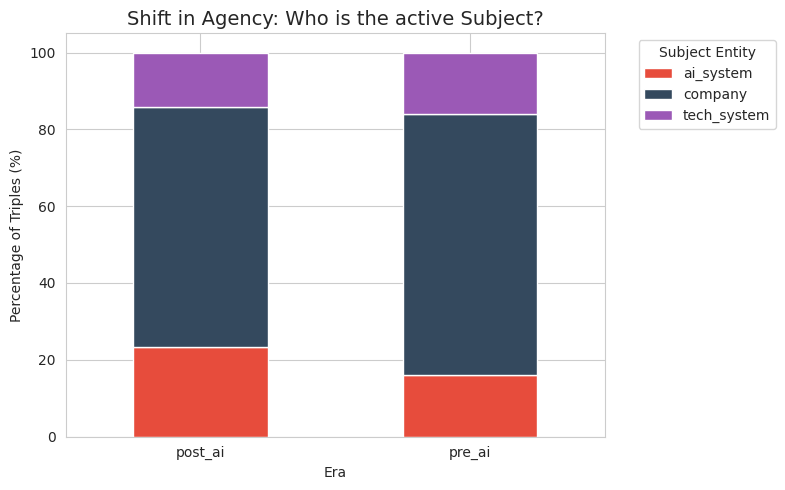

In [36]:
# ======================================================================
# Shift in Agency (The "Scapegoat" Hypothesis)
# ======================================================================

print("=" * 70)
print("THE SCAPEGOAT HYPOTHESIS: Does agency shift from Company to AI?")
print("=" * 70)

# We only care about how blame shifts between these three core actors
focus_cats = ["company", "tech_system", "ai_system"]
focus_triples = df_triples[df_triples['subject_category'].isin(focus_cats)]

scapegoat_dist = pd.crosstab(focus_triples["era"], focus_triples["subject_category"], normalize="index") * 100
print(scapegoat_dist.round(1))

# Plot the Scapegoat Shift
# Use a colormap instead of a fixed color list (handles any number of columns)
ax = scapegoat_dist.plot(kind="bar", stacked=True, figsize=(8, 5), colormap="Set2")
plt.title("Shift in Agency: Who is the active Subject?", fontsize=14)
plt.ylabel("Percentage of Triples (%)")
plt.xlabel("Era")
plt.xticks(rotation=0)
# Ensure labels are perfectly readable
plt.legend(title="Subject Entity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
# ======================================================================
# Anthropomorphism vs. Mechanical Verbs
# ======================================================================
from collections import Counter

print("=" * 70)
print("ANTHROPOMORPHISM: When Technology acts, is it Cognitive or Mechanical?")
print("=" * 70)

# Isolate sentences where technology is the Subject
tech_agents = df_triples[df_triples['subject_category'].isin(['ai_system', 'tech_system'])]
meaningful_tech_actions = tech_agents[~tech_agents['verb_category'].isin(['auxiliary_stop', 'other'])]

if not meaningful_tech_actions.empty:
    anthro_dist = pd.crosstab(meaningful_tech_actions["era"], meaningful_tech_actions["verb_category"], normalize="index") * 100
    print(anthro_dist.round(1))

    # Show the exact raw verbs driving these categories to give flavor to your paper
    pre_ai_verbs = Counter([v.lower() for v in meaningful_tech_actions[meaningful_tech_actions['era'] == 'pre_ai']['verb']]).most_common(5)
    post_ai_verbs = Counter([v.lower() for v in meaningful_tech_actions[meaningful_tech_actions['era'] == 'post_ai']['verb']]).most_common(5)

    print("\nTop Exact Verbs used by Tech (PRE-AI):")
    for v, c in pre_ai_verbs: print(f"  - {v} ({c})")

    print("\nTop Exact Verbs used by Tech (POST-AI):")
    for v, c in post_ai_verbs: print(f"  - {v} ({c})")
else:
    print("Not enough specific tech action verbs found.")

ANTHROPOMORPHISM: When Technology acts, is it Cognitive or Mechanical?
verb_category  cognitive_autonomous  communicative  impact_disruption  \
era                                                                     
post_ai                        11.1           55.6               33.3   
pre_ai                         25.0           25.0               25.0   

verb_category  mechanical_technical  
era                                  
post_ai                         0.0  
pre_ai                         25.0  

Top Exact Verbs used by Tech (PRE-AI):
  - promote (1)
  - is design (1)
  - could not prevent (1)
  - fail (1)

Top Exact Verbs used by Tech (POST-AI):
  - measure (1)
  - warn (1)
  - suffer (1)
  - announce (1)
  - has promise (1)


In [38]:
# ======================================================================
# The Obfuscation of Blame (Targeted Passive Voice)
# ======================================================================
from scipy import stats

print("=" * 70)
print("OBFUSCATION OF BLAME: Passive Voice when discussing Impacts")
print("=" * 70)

# We want to isolate sentences where the OBJECT is the infrastructure or the public,
# OR the verb semantically indicates harm/disruption.
impact_triples = df_triples[
    (df_triples['object_category'].isin(['tech_system', 'user_public'])) |
    (df_triples['verb_category'] == 'impact_disruption')
]

passive_impact_rate = impact_triples.groupby("era")["is_passive"].mean() * 100
print("Passive Voice Usage during Disruption/Impact descriptions:")
print(passive_impact_rate.round(2).astype(str) + "%")

# Statistical chi-square test for this specific subset
ct = pd.crosstab(impact_triples["era"], impact_triples["is_passive"])
if ct.shape == (2, 2):
    chi2, p, _, _ = stats.chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f"\nChi-square Test (Impact Sentences): χ²={chi2:.2f}, p={p:.4f} {sig}")

print("\nExamples of Post-AI Passive Obfuscation:")
sample_passive = impact_triples[(impact_triples['era'] == 'post_ai') & (impact_triples['is_passive'] == True)]

for _, row in sample_passive.head(4).iterrows():
    print(f" - \"{row['sentence']}\"")
    print(f"    (Subject: [{row['subject_category']}] {row['subject']} | Verb: {row['verb']} | Object: [{row['object_category']}] {row['object']})\n")

OBFUSCATION OF BLAME: Passive Voice when discussing Impacts
Passive Voice Usage during Disruption/Impact descriptions:
era
post_ai    15.69%
pre_ai      4.76%
Name: is_passive, dtype: object

Chi-square Test (Impact Sentences): χ²=0.78, p=0.3778 n.s.

Examples of Post-AI Passive Obfuscation:
 - "A line of AI-written code deep in a major provider – such as Amazon, Google or Microsoft – is triggered unexpectedly and causes a cascading software crash."
    (Subject: [ai_system] A line of AI - written code deep | Verb: is trigger | Object: [other] [none])

 - "Four months later, and the tech company was left scrambling to fix a devastating global outage on Monday that left thousands of businesses in limbo – and shed light on the UK government’s reliance on its cloud computing business, Amazon Web Services (AWS)."
    (Subject: [company] the tech company | Verb: was leave | Object: [other] [none])

 - "Last year, airports, healthcare services and businesses worldwide were hit by the “larges

---
## Module 4: Narrative Device Analysis

**Goal:** Understand *how* journalists make technical failures digestible for a general audience.

We measure five narrative strategies:

1. **Metaphor & Analogy** — mapping technical concepts to everyday experience
2. **Anecdotal Leads** — opening with a personal story before the technical explanation
3. **Expert Sourcing** — quoting named experts vs anonymous sources
4. **Scale Framing** — how the magnitude of impact is communicated
5. **Explanatory Depth** — does the article attempt to explain the technical root cause?

This directly addresses your research question about the gap between technical
reality and public framing.

In [43]:
# ======================================================================
# Semantic Metaphor & Narrative Device Detection
# ======================================================================
import re

print("Scanning highly-relevant AI sentences for narrative devices...")

# 1. Define our markers
# NOTE: Removed standalone r"\blike a\b" (too noisy — matches "would like a",
# "like a normal day") and r"\bimagine\b" (rhetorical, not metaphorical).
# Added "akin to", "reminiscent of", "compared to", "much like", "as though".
METAPHOR_MARKERS = [
    r"\bas if\b", r"\bsimilar to\b", r"\bequivalent of\b",
    r"\banalog(?:y|ous)\b", r"\bmetaphor\b",
    r"\bthink of it as\b", r"\bin other words\b", r"\bto put it simply\b",
    r"\bakin to\b", r"\breminiscent of\b", r"\bcompared to\b",
    r"\bmuch like\b", r"\bas though\b",
    # "like a" only when preceded by is/was/felt/looked/seemed to reduce noise
    r"\b(?:is|was|felt|looked|seemed|sounds?)\s+like\s+a\b",
]

TECHNICAL_EXPLANATION_MARKERS = [
    r'(root cause|post.?mortem|investigation found|technical (details|explanation))',
    r'(what (actually |)happened|how .+ (works|failed))',
    r'(the (bug|error|flaw|issue) (was|involved|stemmed))',
    # Require technical terms to co-occur with failure/explanation context,
    # not just appear in isolation (avoids 'seat configuration', 'routing traffic')
    r'((?:configuration|deployment|kernel|driver|endpoint|api|dns|bgp|routing).{0,30}(?:caus|fail|crash|error|bug|issue|broke|problem))',
    r'((?:caus|fail|crash|error|bug|issue|broke|problem).{0,30}(?:configuration|deployment|kernel|driver|endpoint|api|dns|bgp|routing))',
    r'(in (simple|technical) terms)',
    r'(the (update|patch|change) that)',
]

def contains_pattern(text, patterns):
    text = str(text).lower()
    return any(re.search(p, text, re.IGNORECASE) for p in patterns)

# 2. Flag sentences using regex
df_ai_relevant['has_potential_metaphor'] = df_ai_relevant['sentence'].apply(lambda t: contains_pattern(t, METAPHOR_MARKERS))
df_ai_relevant['has_technical_explanation'] = df_ai_relevant['sentence'].apply(lambda t: contains_pattern(t, TECHNICAL_EXPLANATION_MARKERS))

# 3. THE ZERO-SHOT UPGRADE: Filter out false-positive metaphors
# Only send regex-flagged sentences to the model (much smaller subset)
print("Using Zero-Shot to verify true metaphors/analogies...")

potential_metaphors = df_ai_relevant[df_ai_relevant['has_potential_metaphor']].copy()

if len(potential_metaphors) > 0:
    metaphor_labels = [
        "a metaphorical comparison or analogy used to explain a concept",
        "a literal statement, preference, or simple description"
    ]
    
    def metaphor_map_fn(result):
        return result['labels'][0] == "a metaphorical comparison or analogy used to explain a concept"
    
    metaphor_results = classify_zero_shot(
        potential_metaphors['sentence'].tolist(),
        metaphor_labels,
        metaphor_map_fn
    )
    
    # Map results back: True/False for the flagged subset, False for everything else
    metaphor_map = dict(zip(potential_metaphors.index, metaphor_results))
    df_ai_relevant['is_true_metaphor'] = df_ai_relevant.index.map(
        lambda idx: metaphor_map.get(idx, False)
    )
else:
    df_ai_relevant['is_true_metaphor'] = False

print(f"Regex found {df_ai_relevant['has_potential_metaphor'].sum()} potential metaphors.")
print(f"Zero-Shot verified {df_ai_relevant['is_true_metaphor'].sum()} TRUE metaphors.")

Scanning highly-relevant AI sentences for narrative devices...
Using Zero-Shot to verify true metaphors/analogies...
Regex found 2 potential metaphors.
Zero-Shot verified 2 TRUE metaphors.



HOW IS AI EXPLAINED? (Metaphor vs. Technical Depth)
        is_true_metaphor has_technical_explanation
era                                               
post_ai            0.51%                     3.55%
pre_ai              1.1%                      2.2%


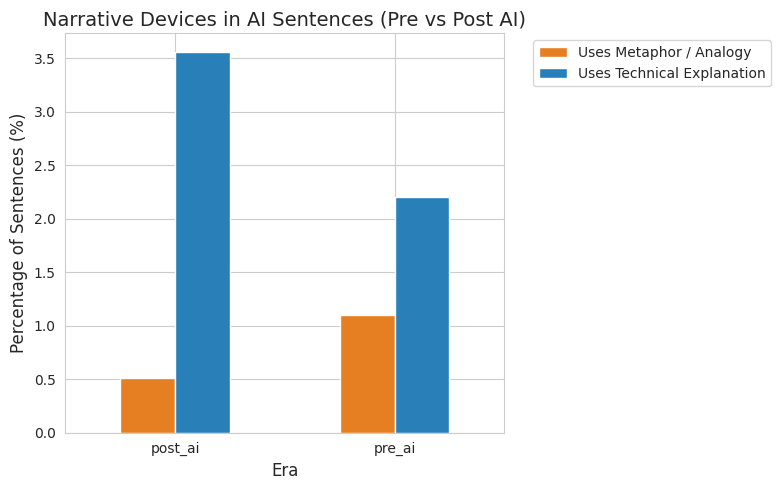

In [44]:
# ======================================================================
# CELL 12 & 13: Narrative Device Comparison by Era
# ======================================================================

print("\n" + "="*70)
print("HOW IS AI EXPLAINED? (Metaphor vs. Technical Depth)")
print("="*70)

# Calculate the percentage of AI sentences that use these devices
narrative_summary = df_ai_relevant.groupby('era')[['is_true_metaphor', 'has_technical_explanation']].mean() * 100
print(narrative_summary.round(2).astype(str) + "%")

# Plot the changing framing strategies
ax = narrative_summary.plot(kind="bar", figsize=(8, 5), color=["#e67e22", "#2980b9"])
plt.title("Narrative Devices in AI Sentences (Pre vs Post AI)", fontsize=14)
plt.ylabel("Percentage of Sentences (%)", fontsize=12)
plt.xlabel("Era", fontsize=12)
plt.xticks(rotation=0)
plt.legend(["Uses Metaphor / Analogy", "Uses Technical Explanation"], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [45]:
# ======================================================================
# Extract Verified Metaphor Examples
# ======================================================================

print("\n" + "="*70)
print("VERIFIED METAPHOR / ANALOGY EXAMPLES BY ERA")
print("(For qualitative close reading in your paper)")
print("="*70)

for era in ["pre_ai", "post_ai"]:
    print(f"\n--- {era.upper()} ---")

    metaphor_sents = df_ai_relevant[(df_ai_relevant["era"] == era) & (df_ai_relevant["is_true_metaphor"])]

    if metaphor_sents.empty:
        print("  [None found in this era]")
    else:
        for _, row in metaphor_sents.head(8).iterrows():
            print(f"  • {row['sentence']} \n    (Event: {row['event']})\n")


VERIFIED METAPHOR / ANALOGY EXAMPLES BY ERA
(For qualitative close reading in your paper)

--- PRE_AI ---
  • She explained that the algorithms recommend content similar to what users have shared, viewed or clicked on in the past – creating a feedback loop that some vulnerable teens cannot escape. 
    (Event: facebook_2021)


--- POST_AI ---
  • Investor anxiety over the possible inflation of a market bubble in AI-related investment similar to overinvestment in the mid-to-late 1990s have been growing. 
    (Event: azure_2025)

